In [1]:
%load_ext autoreload
%autoreload 2

# Torchvision Maskrcnn on Volpy Datfa 

Created by Changjia Cai, Erik Thompson, and Manuel Paez

Date Created: August 28th, 2024

Date Updated: July 7th, 2025

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage.color import rgb2gray, gray2rgb
import torch
from torch.optim.lr_scheduler import CyclicLR
from torchvision import tv_tensors

from model import get_model_instance_segmentation, mrcnn_inference 
from neurons import NeuronsDataset, data_transform
from utils import ScaleImage, collate_fn, nf_match_neurons_in_binary_masks, normalize_image 
from utils import thresholded_predictions, vp_load_image 
from visualize import apply_masks, draw_boxes

In [3]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


## Inspect VolPy data

There are 24 datasets in total, 3 types of different voltage imaging datasets recorded from mouse L1 cortex (L1), mouse hippocampus (HPC), and zebrafish tegmental area (TEG). Set up the image directories from https://zenodo.org/records/4515768 as follows:

    volpy_training_data/
        images/
            HPC.29.04.npz
            ...
        masks/
            HPC.29.04_mask.npz
            ...        
            
The following `data_dir` variable should be directed to `volpy_training_data`

In [4]:
data_dir = r'/mnt/home/mpaez/ceph/volpy_training_data/' #changeable
image_dir = data_dir + 'images/' 
image_path_list = list(sorted(os.listdir(os.path.join(data_dir, "images"))))
mask_path_list = list(sorted(os.listdir(os.path.join(data_dir, "masks"))))

In [5]:
# Load one Image and Masks
dat_ind = 12
data_path = image_path_list[dat_ind]  
mask_path = mask_path_list[dat_ind] 
print(f'image name: {data_path}')
print(f'mask name: {mask_path}')

data_loaded = np.load(data_dir + 'images/' + data_path)
masks_loaded = np.load(data_dir + 'masks/' + mask_path, allow_pickle=True)
image = data_loaded['img']
masks = masks_loaded['mask']
image_gray = rgb2gray(image)
num_masks = len(masks)
print(f'image shape: {image.shape}, number of masks: {num_masks}')

image_tensor = torch.from_numpy(image).permute(2,0,1)
image_tensor = tv_tensors.Image(image_tensor)

image name: L1.00.00.npz
mask name: L1.00.00_mask.npz
image shape: (512, 128, 3), number of masks: 79


Plot the Volpy Segmentation (with Parameters initialized as below)

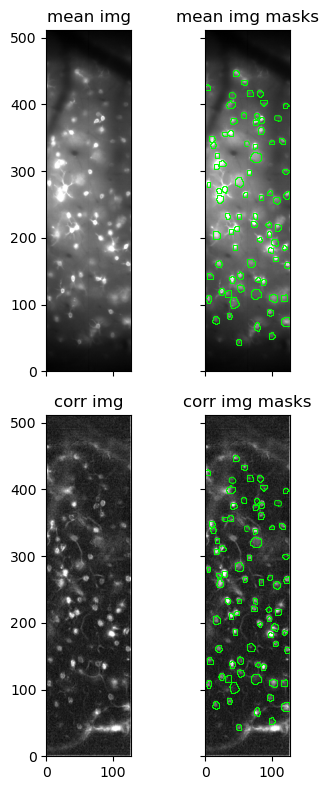

In [6]:
max_v = 99
outline_color = 'lime'
outline_width = 0.75
figsize = (4,8)

f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=figsize, sharex=True, sharey=True)  # w/h
# mean img
ax1.imshow(image[:,:,1], cmap='gray', vmax=np.percentile(image[:,:,1], max_v))
ax1.set_title('mean img')
ax2.imshow(image[:,:,1], cmap='gray', vmax=np.percentile(image[:,:,1], max_v))
for mask in masks:
    ax2.plot(mask['all_points_x'], mask['all_points_y'], 
             color=outline_color, linewidth=outline_width)
ax2.set_title('mean img masks')

# corr img
ax3.imshow(image[:,:,2], cmap='gray', vmax=np.percentile(image[:,:,2], max_v))
ax3.set_title('corr img')
ax4.imshow(image[:,:,2], cmap='gray', vmax=np.percentile(image[:,:,2], max_v))
for mask in masks:
    ax4.plot(mask['all_points_x'], mask['all_points_y'], 
             color=outline_color, linewidth=outline_width)
ax4.set_title('corr img masks')
plt.xlim([0, image.shape[1]-1])
plt.ylim([0, image.shape[0]-1])
plt.tight_layout()

### Define the Dataset

Building on the standard `torch.utils.data.Dataset`class, we use 'NeuronsDataset' from neurons.py. The  `__getitem__` method of this class should return an `image` and a `target` dictionary delineating the different objects (box/mask) in the image:

    image: torchvision.tv_tensors.Image of shape [3, H, W]: can be a pure tensor, or a PIL Image of size (H, W)
    target: a dict containing the following keys
        masks : torchvision uint8 binary masks for each object (N,H,W) (N masks)
        boxes (bounding boxes)  (nx4)
        labels (int) label for each bounding box (note 0 is background, so if you have no bg, start with 1)
        image_id (int) unique image id
        area (float) area of bounding box 
        iscrowd (uint8) instances with `iscrowd=True` will be ignored during evaluation 

The 'data_transform' function from neurons.py should return a training pipeline for training. 
For windows, set the number of workers to 0. Otherwise, set to 4+

#### Check Dataset
Make sure everything is working

In [7]:
num_torch_workers = 0
volpy_data = NeuronsDataset(data_dir, data_transform(train=True))
volpy_dataloader = torch.utils.data.DataLoader(volpy_data,
                                               batch_size=6,
                                               shuffle=True,
                                               num_workers=num_torch_workers,
                                               collate_fn=collate_fn)

print(len(volpy_data))

session_ind = 17
orig_image, orig_image_path = vp_load_image(image_dir, image_path_list, session_ind) # orig data and masks
dataset_image, dataset_target = volpy_data[session_ind] # data after transformation

summary_mn = gray2rgb(normalize_image(dataset_image[1,:,:]))
summary_corr = gray2rgb(normalize_image(dataset_image[2,:,:]))
data_masks = dataset_target['masks']
data_boxes = dataset_target['boxes']

24


#### Visualize Transformed Data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4190567].


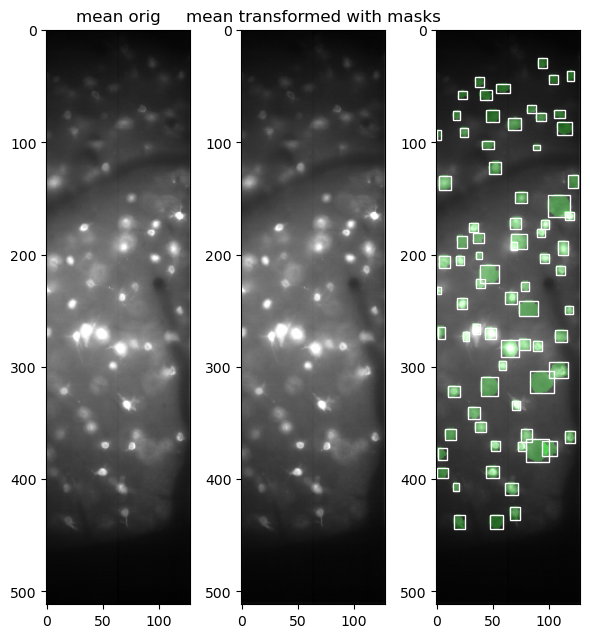

In [8]:
mask_color = (0, 1, 0)
plot_box = True
box_color = 'white'
alpha = 0.001

masked_mn_vp = apply_masks(summary_mn, data_masks, mask_color, alpha=alpha)
f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(6, 12))
ax1.imshow(orig_image[:,:,0], cmap='gray', vmax=np.percentile(orig_image[:,:,0], 99.5))
ax1.set_title('mean orig')
ax2.imshow(summary_mn[:, :, 0], cmap='gray',  vmax=np.percentile(summary_mn, 99.5))
ax2.set_title('mean transformed')
ax3.imshow(masked_mn_vp)
ax2.set_title('mean transformed with masks')
if plot_box:
    ax3, rects = draw_boxes(data_boxes, color=box_color, line_width=1, ax=ax3)  
plt.tight_layout()

#### Check Dataloader
Note: Dataloader is an iterable

In [9]:
batch_images, batch_targets = next(iter(volpy_dataloader))

# standard way of extracting images and targets for a batch into a list
batch_images = list(image for image in batch_images)
batch_targets = [{k: v for k, v in t.items()} for t in batch_targets]

# check one sample
batch_ind = 0
batch_item_target = batch_targets[batch_ind]
batch_item_image = batch_images[batch_ind]
batch_item_id = batch_item_target['image_id']

# extract original image so we can compare
image_orig, image_orig_path = vp_load_image(image_dir, image_path_list, batch_item_id)

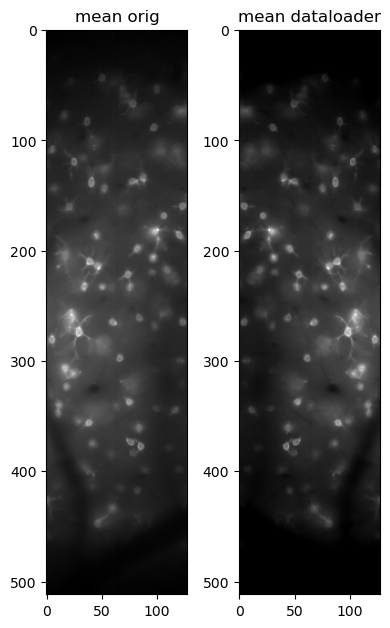

In [10]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(4,8))
ax1.imshow(image_orig[:,:,0], cmap='gray')
ax1.set_title('mean orig')
ax2.imshow(batch_item_image[0,:,:], cmap='gray')
ax2.set_title('mean dataloader')
plt.tight_layout()

## Training and Volpy

### Train and Validation Sets


In [11]:
# use our dataset and defined transformations
num_classes = 2
num_test = 8

# training and test datasets defined (this will determine which transforms are applied)
dataset = NeuronsDataset(data_dir, data_transform(train=True))
dataset_val = NeuronsDataset(data_dir, data_transform(train=False))

print(f"We have {len(dataset)} different volpy datasets to use for training/testing")

# here we select two thirds of datasets for training, one third of datasets for testing
# we make sure each type of datasets (L1, TEG, HPC) has at least one dataset for testing
indices = [4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 18, 19, 20, 22, 23, 0, 1, 2, 3, 12, 13, 14, 21]
dataset = torch.utils.data.Subset(dataset, indices[:-num_test])
dataset_val = torch.utils.data.Subset(dataset_val, indices[-num_test:])

print(f'training sets: {indices[:-num_test]}')
print(f'test sets: {indices[-num_test:]}')

num_torch_workers = 0  # this is necessary for windows. In other OS set to 4+
data_loader = torch.utils.data.DataLoader(dataset,
                                          batch_size=2,
                                          shuffle=True,
                                          num_workers=num_torch_workers,
                                          collate_fn=collate_fn);
data_loader_val = torch.utils.data.DataLoader(dataset_val,
                                               batch_size=1,
                                               shuffle=False,
                                               num_workers=num_torch_workers,
                                               collate_fn=collate_fn)

print(f'number of batches per epoch for training {len(data_loader)}')

We have 24 different volpy datasets to use for training/testing
training sets: [4, 5, 6, 7, 8, 9, 10, 11, 15, 16, 17, 18, 19, 20, 22, 23]
test sets: [0, 1, 2, 3, 12, 13, 14, 21]
number of batches per epoch for training 8


### Model
We use a model pre-trained on the coc dataset

In [12]:
model = get_model_instance_segmentation(num_classes)
model.to(device);

### Optimizer/lr scheduler

In [13]:
max_lr = 0.005
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params,
                            lr=max_lr, # 0.003
                            momentum=0.9,
                            weight_decay=0.0001) #0.0005
optimizer.param_groups[0]["lr"]  # to extract the learning rate

lr_scheduler = CyclicLR(optimizer, 
                     base_lr = 0.000001,     # Initial learning rate which is the lower boundary in the cycle for each parameter group
                     max_lr = max_lr,       # 0.003 Upper learning rate boundaries in the cycle for each parameter group
                     step_size_up = 3,     # Number of training iterations in the increasing half of a cycle
                     step_size_down = 7,
                     mode = "triangular2")

#### Training the Network

In [14]:
model_save_dir = '/mnt/home/mpaez/ceph/volpy_models'
try:
    os.mkdir(model_save_dir)
except:
    pass

num_epochs = 100
print_freq = 1
save_freq = 20
num_train = len(dataset)
num_val = len(dataset_val)

In [15]:
all_train_losses = []
all_val_losses = []
all_lrs = []

print(f"**TRAIN {num_epochs} epochs. PRINT every {print_freq} epoch(s). SAVE every {save_freq} epoch(s).**")

for epoch in range(num_epochs):      
    train_epoch_loss = 0
    val_epoch_loss = 0

    ### TRAIN STEP
    if np.mod(epoch+1, print_freq) == 0:
        print(f"Epoch {epoch+1}")
        
    model.train()
    for i, (images, targets) in enumerate(data_loader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum([loss for loss in loss_dict.values()])
        train_epoch_loss += losses.cpu().detach().numpy()
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
    all_train_losses.append(train_epoch_loss)
    all_lrs.append(optimizer.param_groups[0]["lr"])
    lr_scheduler.step()

    # Validation STEP
    with torch.no_grad():
        for j, (images_val, targets_val) in enumerate(data_loader_val):
            images_val = list(image.to(device) for image in images_val)
            targets_val = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets_val]
            loss_val = model(images_val, targets_val)
            losses_val = sum([l for l in loss_val.values()])
            val_epoch_loss += losses_val.cpu().detach().numpy()
        all_val_losses.append(val_epoch_loss)
        
    if np.mod(epoch+1, print_freq) == 0:
        print("\ttrain/test net loss: ", train_epoch_loss, " ", val_epoch_loss)

    # Save model (if save)
    if np.mod(epoch+1, save_freq) == 0:
        print(f"\tSaving mrcnn epoch {epoch+1}")
        model_fname = 'mrcnn_' + str(epoch+1) + '.pt'
        model_path = model_save_dir + model_fname
        torch.save(model, model_path)

    torch.cuda.empty_cache()  # may help with memory management

history = [all_train_losses, all_val_losses, all_lrs]
torch.save(history, model_save_dir + 'volpy_train_history.pt')
print("\nDONE!")  

**TRAIN 100 epochs. PRINT every 1 epoch(s). SAVE every 20 epoch(s).**
Epoch 1
	train/test net loss:  33.3597686290741   32.48799753189087
Epoch 2
	train/test net loss:  18.044917821884155   17.98798906803131
Epoch 3
	train/test net loss:  15.614665627479553   14.032392501831055
Epoch 4
	train/test net loss:  12.89219617843628   12.368476152420044
Epoch 5
	train/test net loss:  12.07962155342102   11.631637513637543
Epoch 6
	train/test net loss:  11.454606175422668   11.697239220142365
Epoch 7
	train/test net loss:  11.153437614440918   11.610294699668884
Epoch 8
	train/test net loss:  10.685841798782349   11.245052874088287
Epoch 9
	train/test net loss:  10.783626437187195   10.921491205692291
Epoch 10
	train/test net loss:  10.73915946483612   10.791667938232422
Epoch 11
	train/test net loss:  10.42649495601654   10.675180673599243
Epoch 12
	train/test net loss:  10.002458453178406   10.528046369552612
Epoch 13
	train/test net loss:  9.84008276462555   10.141004085540771
Epoch 14
	tra

#### Plot Loss Function

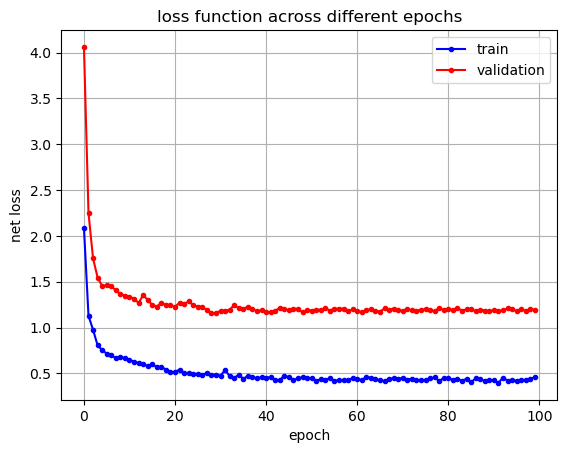

In [16]:
plt.plot(np.array(all_train_losses)/num_train, color='blue', marker='.', label='train')
plt.plot(np.array(all_val_losses)/num_test, color='red', marker='.', label='validation')
plt.legend();
plt.xlabel('epoch')
plt.ylabel('net loss')
plt.title('loss function across different epochs')
plt.grid()

#### Plot Learning Rate vs Epoch

Text(0.5, 1.0, 'learning rate across different epochs')

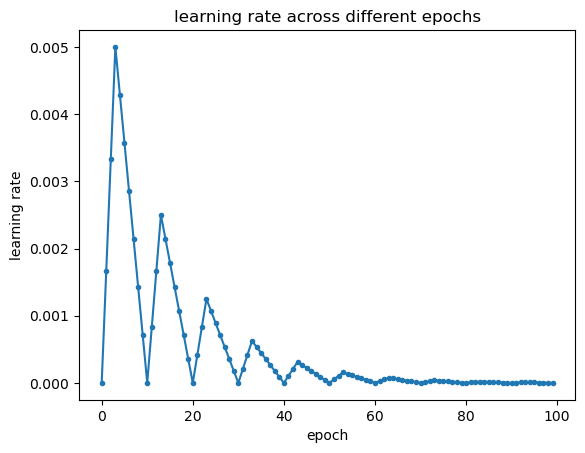

In [17]:
plt.plot(all_lrs, marker='.')
plt.xlabel('epoch')
plt.ylabel('learning rate')
plt.title('learning rate across different epochs')

## Inference using Test Set

In [18]:
# pull original data 
idx = 4
val_set = np.array([0, 1, 2, 3, 12, 13, 14, 21])
volpy_inference_dataset = NeuronsDataset(data_dir, data_transform(train=False))
vp_im, vp_target = volpy_inference_dataset[val_set[idx]]
summary_mn = gray2rgb(normalize_image(vp_im[1,:,:]))
summary_corr = gray2rgb(normalize_image(vp_im[2,:,:]))
data_masks = vp_target['masks']
data_boxes = vp_target['boxes']

#### Run Inference on One Dataset 

In [19]:
# run inference on one dataset
eval_transform = data_transform(train=False)
model.eval()
with torch.no_grad():
    x = eval_transform(vp_im)
    x = x.to(device)
    predictions = model([x, ])
    pred = predictions[0]

# prediction score range
print(f'prediction scores: {pred["scores"]}')

prediction scores: tensor([0.9723, 0.9706, 0.9651, 0.9598, 0.9590, 0.9573, 0.9567, 0.9549, 0.9548,
        0.9517, 0.9461, 0.9437, 0.9418, 0.9393, 0.9385, 0.9367, 0.9362, 0.9346,
        0.9346, 0.9341, 0.9337, 0.9308, 0.9307, 0.9254, 0.9253, 0.9240, 0.9218,
        0.9202, 0.9176, 0.9144, 0.9141, 0.9103, 0.9099, 0.9079, 0.9056, 0.9040,
        0.9005, 0.9001, 0.8995, 0.8981, 0.8975, 0.8932, 0.8903, 0.8901, 0.8847,
        0.8827, 0.8805, 0.8739, 0.8686, 0.8572, 0.8540, 0.8484, 0.8480, 0.8263,
        0.8190, 0.8187, 0.8179, 0.7990, 0.7936, 0.7834, 0.7644, 0.7640, 0.7568,
        0.7533, 0.7288, 0.7129, 0.6956, 0.6481, 0.6244, 0.4877, 0.4715, 0.4610,
        0.4214, 0.2780, 0.2773, 0.2171, 0.1947, 0.1945, 0.1908, 0.1789, 0.1602,
        0.1291, 0.1096, 0.0942, 0.0780, 0.0716, 0.0703, 0.0622, 0.0503],
       device='cuda:0')


In [20]:
thresh = 0.5
predicted_masks, predicted_boxes = thresholded_predictions(pred, threshold=thresh) 
predicted_masks_np = (((0.5+predicted_masks).detach().cpu().numpy())).astype(np.uint8)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.254].


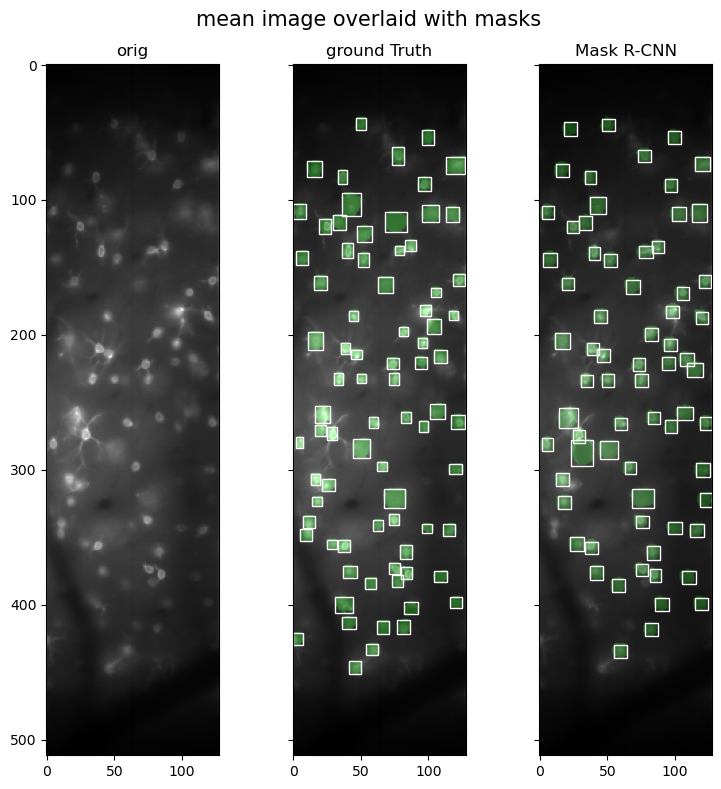

In [21]:
# get masked image of ground truth and predictions
mask_alpha = 0.001
mask_color = (0,1,0)
masked_vp = apply_masks(summary_mn, data_masks, color=mask_color, alpha=mask_alpha) 
masked_pred = apply_masks(summary_mn, predicted_masks_np, color=mask_color, alpha=mask_alpha)
masked_pred = masked_pred/masked_pred.max()

f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(8,8), sharex=True, sharey=True)
ax1.imshow(summary_mn)
ax2.imshow(masked_vp)
ax3.imshow(masked_pred)
if plot_box:
    ax2, rects = draw_boxes(data_boxes, ax=ax2, line_width=1, color='white');
    ax3, rect = draw_boxes(predicted_boxes.detach().cpu().numpy(), ax=ax3, color='white', line_width=1);
ax1.set_title('orig')
ax2.set_title('ground Truth')
ax3.set_title('Mask R-CNN')
plt.suptitle('mean image overlaid with masks', fontsize=15)
plt.tight_layout()

#### Compute F1 score for this dataset

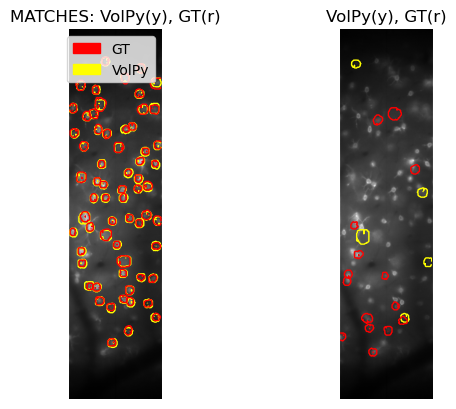

F1 score: 0.8648648648648649


<Figure size 640x480 with 0 Axes>

In [22]:
_, _, _, _, performance = nf_match_neurons_in_binary_masks(data_masks.numpy().astype(np.float64), 
                                 predicted_masks_np.astype(np.float64), 
                                 plot_results=True, Cn=summary_mn, 
                                 labels=['GT', 'VolPy'], 
                                 colors=['red', 'yellow'])
print(f"F1 score: {performance['f1_score']}")

#### Compute F1 score for all test datasets

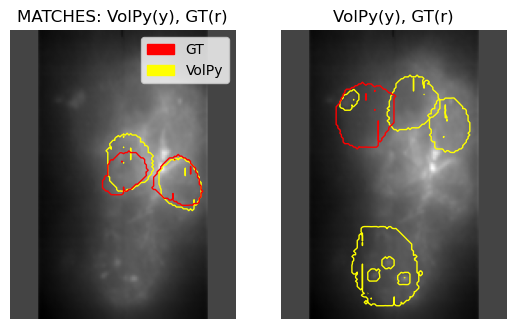

F1 score: 0.3333333333333333


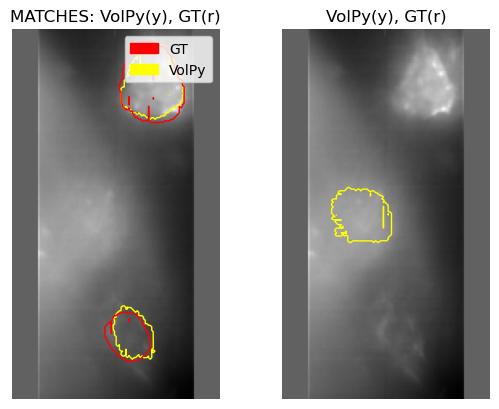

F1 score: 0.8


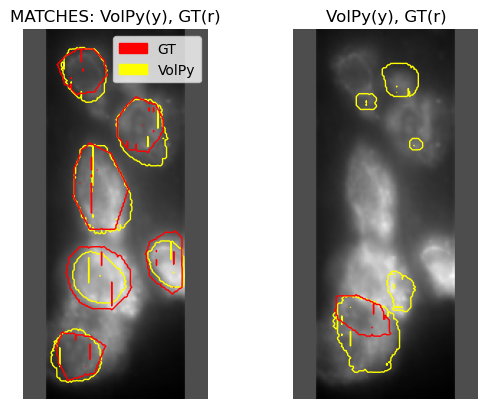

F1 score: 0.6666666666666666


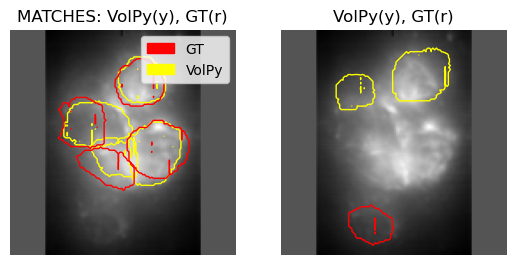

F1 score: 0.7272727272727273


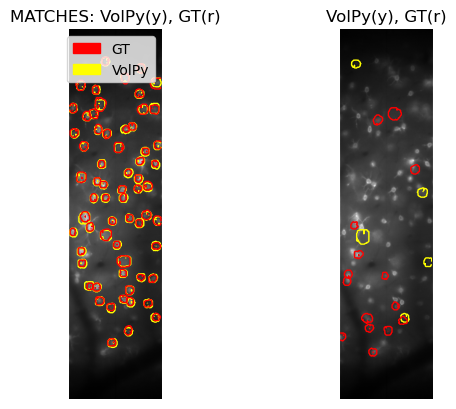

F1 score: 0.8648648648648649


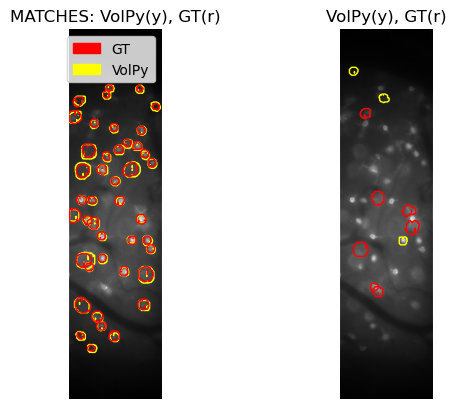

F1 score: 0.8958333333333334


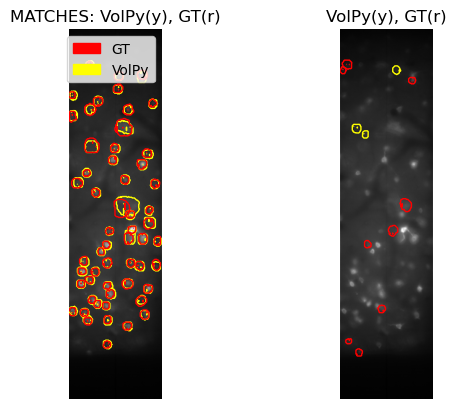

F1 score: 0.9032258064516129


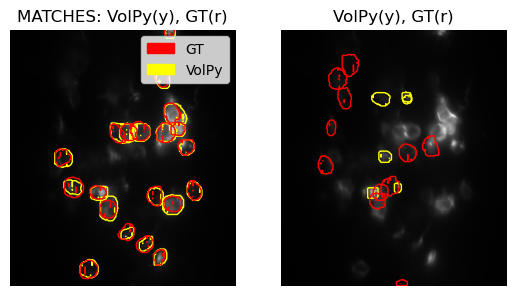

F1 score: 0.7017543859649122
avg F1 score for HPC: 0.6318181818181818
avg F1 score for L1: 0.8879746682166038
avg F1 score for TEG: 0.7017543859649122


<Figure size 640x480 with 0 Axes>

In [23]:
val_set = np.array([0, 1, 2, 3, 12, 13, 14, 21])
eval_transform = data_transform(train=False)
F1_all = []

for idx in val_set:
    vp_im, vp_target = volpy_inference_dataset[idx]
    summary_mn = gray2rgb(normalize_image(vp_im[1,:,:]))
    data_masks = vp_target['masks']
    _, _, binarized_masks = mrcnn_inference(model, img=vp_im, thresh=0.5, 
                                            eval_transform=eval_transform,
                                            device=device)    

    try:
        _, _, _, _, performance = nf_match_neurons_in_binary_masks(data_masks.numpy().astype(np.float64), 
                                         binarized_masks.astype(np.float64), 
                                         plot_results=True, Cn=summary_mn, 
                                         labels=['GT', 'VolPy'], 
                                         colors=['red', 'yellow'])
        print(f"F1 score: {performance['f1_score']}")
        F1_all.append(performance['f1_score'])
        
    except:
        print(0)
        F1_all.append(0)
        

F1_all = np.array(F1_all)    
print(f'avg F1 score for HPC: {F1_all[:4].mean()}')
print(f'avg F1 score for L1: {F1_all[4:7].mean()}')
print(f'avg F1 score for TEG: {F1_all[7]}')